In [1]:
!pip install -q bertopic sentence-transformers umap-learn hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.2 MB/s eta 0:00:00


# Pipeline 2: Sentence-BERT + BERTopic

This notebook applies Sentence-BERT embeddings followed by BERTopic to identify semantically related topics in the same 10,000 consumer complaint narratives used in Pipeline 1.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# Load the same dataset used in Pipeline 1
df = pd.read_csv("/content/complaints_sample_10000.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

Dataset shape: (10000, 3)
Columns: ['product', 'narrative', 'word_count']


,product,narrative,word_count
0,credit_reporting,listed fraudulent someone stol social security...,77
1,debt_collection,collection appeared credit report recently deb...,38
2,credit_reporting,quite year exact first started noticing proble...,236
3,credit_reporting,filing forged document court public record fal...,1397
4,mortgages_and_loans,vehicle put chapter bankruptcy significant una...,74


## Sentence-BERT Embeddings

Sentence-BERT converts each complaint narrative into a dense numerical embedding that captures semantic meaning and contextual similarity. Unlike TF-IDF, this representation can identify relationships between complaints even when they do not use exactly the same words.

In [4]:
# Load a lightweight Sentence-BERT model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Convert complaint narratives into semantic embeddings
documents = df["narrative"].astype(str).tolist()

embeddings = embedding_model.encode(
    documents,
    show_progress_bar=True,
    batch_size=64
)

print("Embedding matrix shape:", embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Embedding matrix shape: (10000, 384)


## BERTopic Topic Modelling

BERTopic clusters the Sentence-BERT embeddings to identify groups of semantically similar complaints. UMAP is used for dimensionality reduction and HDBSCAN for clustering. The model is configured to produce approximately eight main topics so that its results can later be compared with the eight NMF topics from Pipeline 1.


In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Dimensionality reduction
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# Clustering
hdbscan_model = HDBSCAN(
    min_cluster_size=100,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# Words/phrases used to describe each topic
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    min_df=5
)

# Create BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    nr_topics=8,
    calculate_probabilities=False,
    verbose=True
)

# Fit BERTopic using the Sentence-BERT embeddings
topics, _ = topic_model.fit_transform(documents, embeddings)

print("BERTopic modelling completed.")

2026-08-24 22:50:07,148 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-24 22:51:25,007 - BERTopic - Dimensionality - Completed ✓
2026-08-24 22:51:25,009 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-24 22:51:25,989 - BERTopic - Cluster - Completed ✓
2026-08-24 22:51:25,990 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-08-24 22:51:27,885 - BERTopic - Representation - Completed ✓
2026-08-24 22:51:27,886 - BERTopic - Topic reduction - Reducing number of topics
2026-08-24 22:51:27,887 - BERTopic - Topic reduction - Number of topics (8) is equal or higher than the clustered topics(5).
2026-08-24 22:51:27,890 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-24 22:51:29,960 - BERTopic - Representation - Completed ✓


BERTopic modelling completed.


## BERTopic Results

BERTopic identified the topic structure directly from semantic similarity between complaint embeddings. The number of discovered topics may differ from the eight NMF topics because HDBSCAN determines clusters from the data rather than requiring every complaint to belong to a fixed number of topics.

In [6]:
# Display BERTopic topic information
topic_info = topic_model.get_topic_info()

print("BERTopic topic information:")
display(topic_info)

BERTopic topic information:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,567,-1_information_account_credit_report,"[information, account, credit, report, opened,...",[legal department credit dispute submitted new...
1,0,119,0_link_account_bank_allow,"[link, account, bank, allow, bank account, try...",[im trying link bank account another financial...
2,1,130,1_money_account_transaction_refund,"[money, account, transaction, refund, email, f...",[reference using paypal credit ordered dress d...
3,2,5019,2_credit_report_account_information,"[credit, report, account, information, company...",[year found identity stolen checked credit rep...
4,3,4165,3_payment_account_loan_bank,"[payment, account, loan, bank, would, card, cr...",[opened secure credit card owed one payment ba...


In [7]:
# Display the top 10 words for each discovered BERTopic topic
for topic_id in topic_info["Topic"]:
    if topic_id == -1:
        continue

    words = topic_model.get_topic(topic_id)[:10]
    top_words = [word for word, score in words]

    print(f"Topic {topic_id}: {', '.join(top_words)}")

Topic 0: link, account, bank, allow, bank account, trying, money, app, use, apps
Topic 1: money, account, transaction, refund, email, fund, item, sent, payment, purchase
Topic 2: credit, report, account, information, company, letter, sent, please, number, item
Topic 3: payment, account, loan, bank, would, card, credit, time, told, called


## BERTopic Topic Validation

Representative complaints are inspected for each BERTopic cluster to support meaningful topic labels and verify that the semantic clusters correspond to coherent complaint themes.

In [8]:
# Inspect representative complaints for each BERTopic topic
for topic_id in topic_info["Topic"]:
    if topic_id == -1:
        continue

    print(f"\nTopic {topic_id}")
    print("Top words:")
    print([word for word, score in topic_model.get_topic(topic_id)[:10]])

    print("\nRepresentative complaints:")
    representative_docs = topic_model.get_representative_docs(topic_id)

    for i, doc in enumerate(representative_docs[:3], start=1):
        print(f"{i}. {doc[:500]}")
        print()

    print("-" * 100)


Topic 0
Top words:
['link', 'account', 'bank', 'allow', 'bank account', 'trying', 'money', 'app', 'use', 'apps']

Representative complaints:
1. im trying link bank account another financial app bank telling link account

2. trying link bank account stock market ca

3. friday tried link pnc bank account allow

----------------------------------------------------------------------------------------------------

Topic 1
Top words:
['money', 'account', 'transaction', 'refund', 'email', 'fund', 'item', 'sent', 'payment', 'purchase']

Representative complaints:
1. reference using paypal credit ordered dress disguised website paying realized mistake canceled order per website within hour prior shipping product contacted first time request refund time making request since filed dispute paypal stating could communicate seller wanted payment refunded paypal gave seller opportunity send product dress closed case product seller sent cheap necklace opened new dispute item described paypal given da

## BERTopic Labels and Prevalence

The representative complaints were inspected to assign meaningful labels to the BERTopic clusters. BERTopic produced four main semantic topics and an additional outlier group. Unlike NMF, which divided the complaints into eight more specific topics, BERTopic created fewer and broader clusters based on semantic similarity.

In [9]:
# Assign meaningful labels to BERTopic topics
bertopic_labels = {
    -1: "Outliers / Unassigned",
    0: "Bank Account Linking Issues",
    1: "Digital Payments, Transactions & Refunds",
    2: "Credit Reporting & Account Disputes",
    3: "Banking, Loan & Payment Issues"
}

# Add BERTopic assignments to the dataframe
df["bertopic_topic"] = topics
df["bertopic_topic_label"] = df["bertopic_topic"].map(bertopic_labels)

# Calculate topic prevalence
bertopic_counts = df["bertopic_topic_label"].value_counts()

print("BERTopic topic prevalence:")
print(bertopic_counts)

print("\nTopic percentages:")
print((bertopic_counts / len(df) * 100).round(2))

BERTopic topic prevalence:
bertopic_topic_label
Credit Reporting & Account Disputes         5019
Banking, Loan & Payment Issues              4165
Outliers / Unassigned                        567
Digital Payments, Transactions & Refunds     130
Bank Account Linking Issues                  119
Name: count, dtype: int64

Topic percentages:
bertopic_topic_label
Credit Reporting & Account Disputes         50.19
Banking, Loan & Payment Issues              41.65
Outliers / Unassigned                        5.67
Digital Payments, Transactions & Refunds     1.30
Bank Account Linking Issues                  1.19
Name: count, dtype: float64


## BERTopic Topic Prevalence Visualization

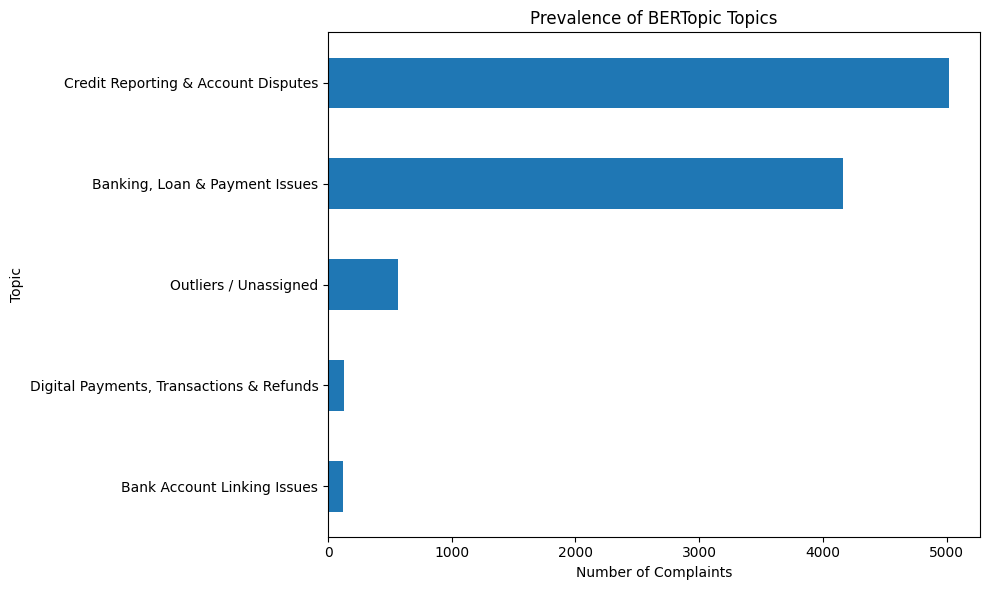

In [10]:
plt.figure(figsize=(10, 6))

bertopic_counts.sort_values().plot(kind="barh")

plt.title("Prevalence of BERTopic Topics")
plt.xlabel("Number of Complaints")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

## Interpretation and Limitations

The Sentence-BERT + BERTopic pipeline identified four main semantic topics and an additional outlier group. The largest topic was Credit Reporting & Account Disputes, representing 50.19% of complaints, followed by Banking, Loan & Payment Issues at 41.65%.

Compared with TF-IDF + NMF, BERTopic produced fewer and broader topics. This suggests that semantic embeddings grouped complaints with related meanings even when their vocabulary differed. The two smaller topics captured more specific issues involving bank-account linking and digital payment or refund transactions.

A limitation is that BERTopic assigned 5.67% of complaints to the outlier group, meaning they did not belong confidently to any discovered cluster. In addition, the two largest topics are broad and combine several related financial issues. These differences will be examined directly in the final comparison between both pipelines.

In [11]:
# Save complaint-level BERTopic assignments
bertopic_results = df[
    ["product", "narrative", "word_count",
     "bertopic_topic", "bertopic_topic_label"]
].copy()

bertopic_results.to_csv(
    "/content/bertopic_topic_assignments.csv",
    index=False
)

# Save prevalence summary
bertopic_summary = pd.DataFrame({
    "topic": bertopic_counts.index,
    "count": bertopic_counts.values,
    "percentage": (
        bertopic_counts.values / len(df) * 100
    ).round(2)
})

bertopic_summary.to_csv(
    "/content/bertopic_topic_summary.csv",
    index=False
)

print("BERTopic results saved successfully.")
display(bertopic_summary)

BERTopic results saved successfully.


,topic,count,percentage
0,Credit Reporting & Account Disputes,5019,50.19
1,"Banking, Loan & Payment Issues",4165,41.65
2,Outliers / Unassigned,567,5.67
3,"Digital Payments, Transactions & Refunds",130,1.30
4,Bank Account Linking Issues,119,1.19
